<a href="https://colab.research.google.com/github/bev-njeri/njeri_tasks/blob/master/DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings as w
import seaborn as sns
w.filterwarnings('ignore')

In [ ]:

Datasetsalary_2024 = pd.read_csv('/content/Dataset salary 2024.csv')
Datasetsalary_2024.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [ ]:
Datasetsalary_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [ ]:
Datasetsalary_2024.duplicated().sum()

np.int64(6421)

In [ ]:
Datasetsalary_2024[Datasetsalary_2024.duplicated()]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
62,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
151,2024,SE,FT,Research Analyst,130000,USD,130000,US,0,US,M
238,2024,MI,FT,Data Analyst,95000,USD,95000,US,0,US,M
239,2024,MI,FT,Data Analyst,80000,USD,80000,US,0,US,M
247,2024,SE,FT,Data Scientist,146000,USD,146000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
16235,2022,MI,FT,Data Scientist,78000,USD,78000,US,100,US,M
16236,2022,SE,FT,Data Engineer,135000,USD,135000,US,100,US,M
16237,2022,SE,FT,Data Engineer,115000,USD,115000,US,100,US,M
16376,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L


In [ ]:
Datasetsalary_2024.drop_duplicates(inplace=True)
Datasetsalary_2024.duplicated().sum()

np.int64(0)

In [ ]:
Datasetsalary_2024.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,10113.000000,1.011300e+04,10113.000000,10113.000000
mean,2023.227529,1.698129e+05,146662.179571,35.553248
std,0.783372,4.321347e+05,72697.319441,47.227660
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,9.577600e+04,95000.000000,0.000000
50%,2023.000000,1.400000e+05,138750.000000,0.000000
75%,2024.000000,1.885000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


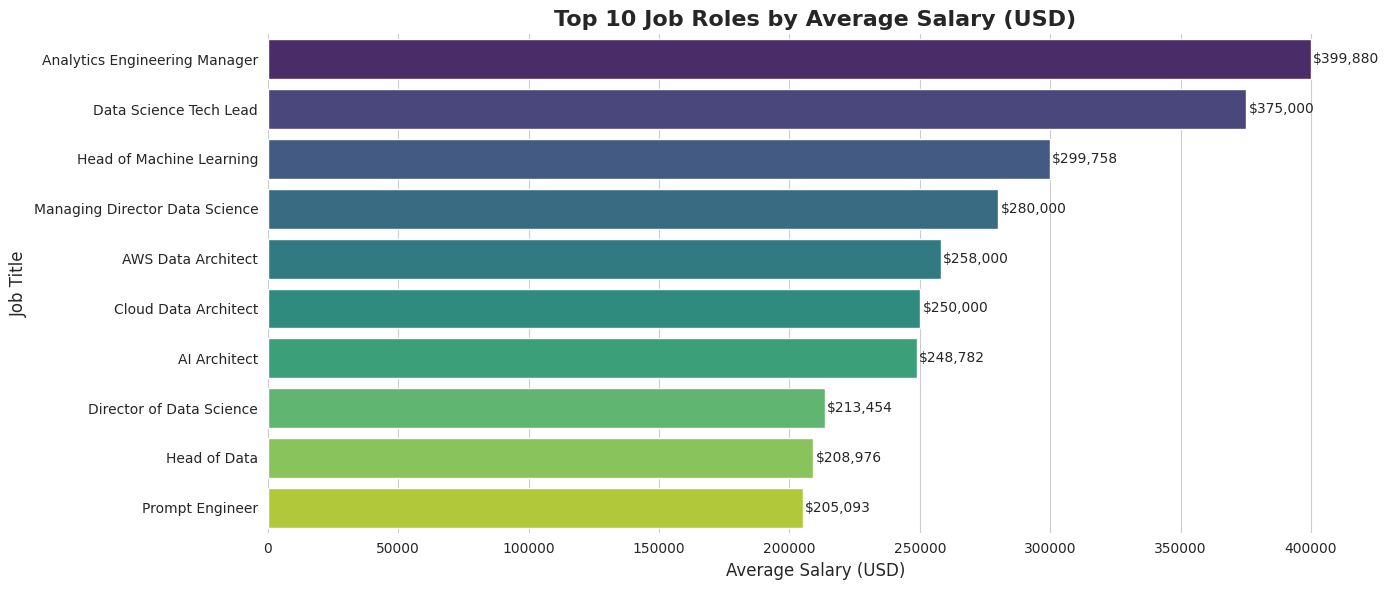

In [ ]:
sns.set_style(style="whitegrid")
Top10_job_roles_by_salary = Datasetsalary_2024.groupby('job_title')['salary_in_usd'] \
                              .mean() \
                              .sort_values(ascending=False) \
                              .head(10)
plt.figure(figsize=(14,6))
ax = sns.barplot(
    x=Top10_job_roles_by_salary.values,
    y=Top10_job_roles_by_salary.index,
    palette="viridis")
plt.title("Top 10 Job Roles by Average Salary (USD)", fontsize=16, weight='bold')
plt.xlabel("Average Salary (USD)", fontsize=12)
plt.ylabel("Job Title", fontsize=12)
plt.ylabel("Job Title", fontsize=12)
for i, v in enumerate(Top10_job_roles_by_salary.values):
    ax.text(v + 1000, i, f"${int(v):,}", va='center', fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

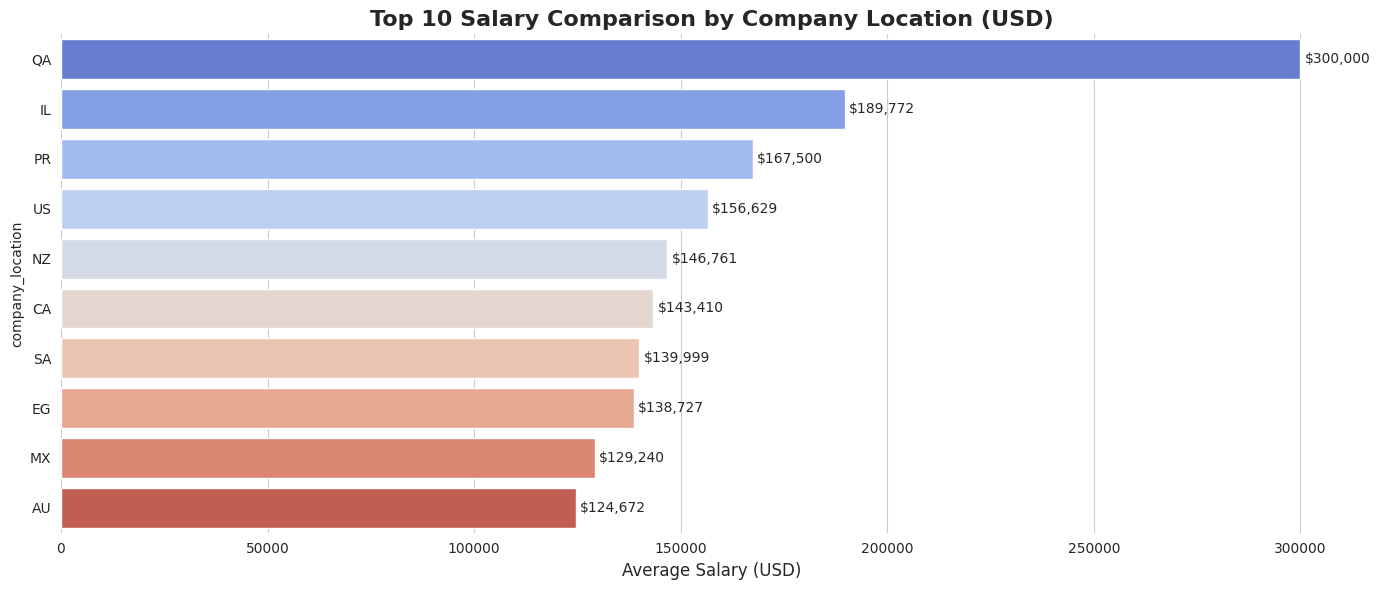

In [ ]:
Top10_company_location_by_salary=Datasetsalary_2024.groupby('company_location')['salary_in_usd']\
                              .mean() \
                              .sort_values(ascending=False) \
                              .head(10)

plt.figure(figsize=(14,6))
ax = sns.barplot(
    x=Top10_company_location_by_salary.values,
    y=Top10_company_location_by_salary.index,
    palette="coolwarm")
plt.title("Top 10 Salary Comparison by Company Location (USD)", fontsize=16, weight='bold')
plt.xlabel("Average Salary (USD)", fontsize=12)
for i, v in enumerate(Top10_company_location_by_salary.values):
    ax.text(v + 1000, i, f"${int(v):,}", va='center', fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

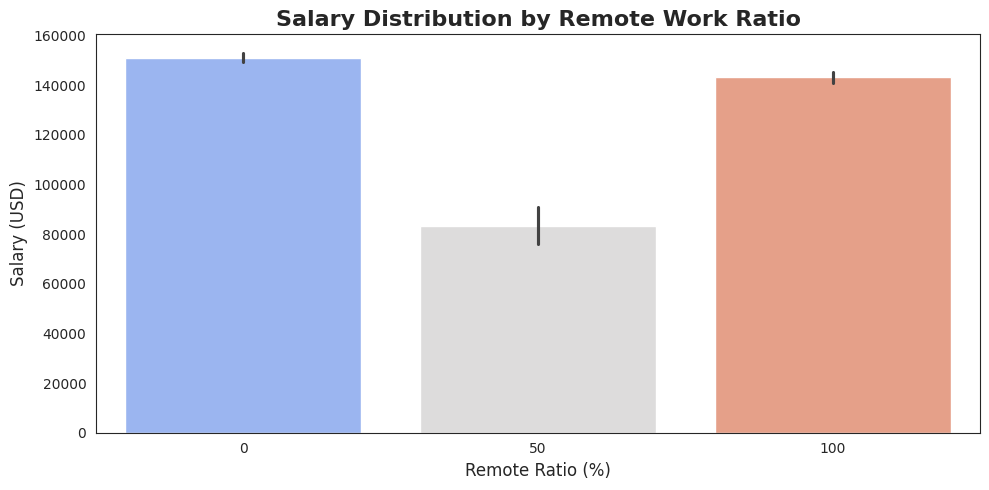

In [ ]:
sns.set_style(style="white")
plt.figure(figsize=(10,5))
ax=sns.barplot(
    x='remote_ratio',
    y='salary_in_usd',
    data=Datasetsalary_2024,
    palette='coolwarm'
)
plt.title("Salary Distribution by Remote Work Ratio", fontsize=16, weight='bold')
plt.xlabel("Remote Ratio (%)", fontsize=12)
plt.ylabel("Salary (USD)", fontsize=12)
plt.tight_layout()
plt.show()

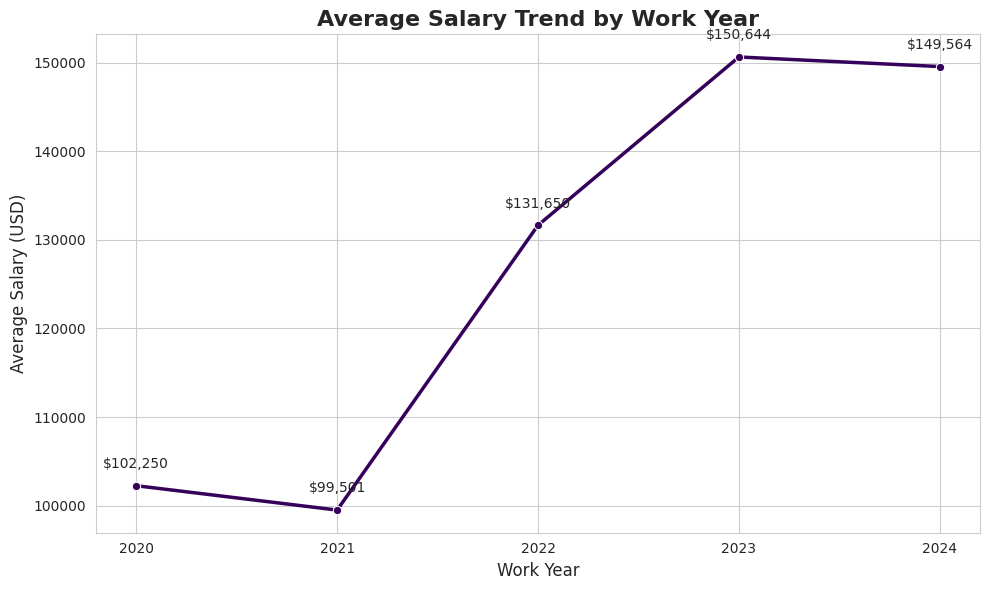

In [ ]:
sns.set_style("whitegrid")
salary_trend = Datasetsalary_2024.groupby('work_year')['salary_in_usd'].mean()
plt.figure(figsize=(10,6))
ax = sns.lineplot(
    x=salary_trend.index,
    y=salary_trend.values,
    marker='o', linewidth=2.5,
    color="#35015B",
)
plt.title("Average Salary Trend by Work Year", fontsize=16, weight='bold')
plt.xlabel("Work Year", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
for x, y in zip(salary_trend.index, salary_trend.values):
    ax.text(x, y + 2000, f"${int(y):,}", ha='center', fontsize=10)
plt.tight_layout()
plt.xticks(salary_trend.index)
plt.show()

Text(0, 0.5, 'Salary (USD)')

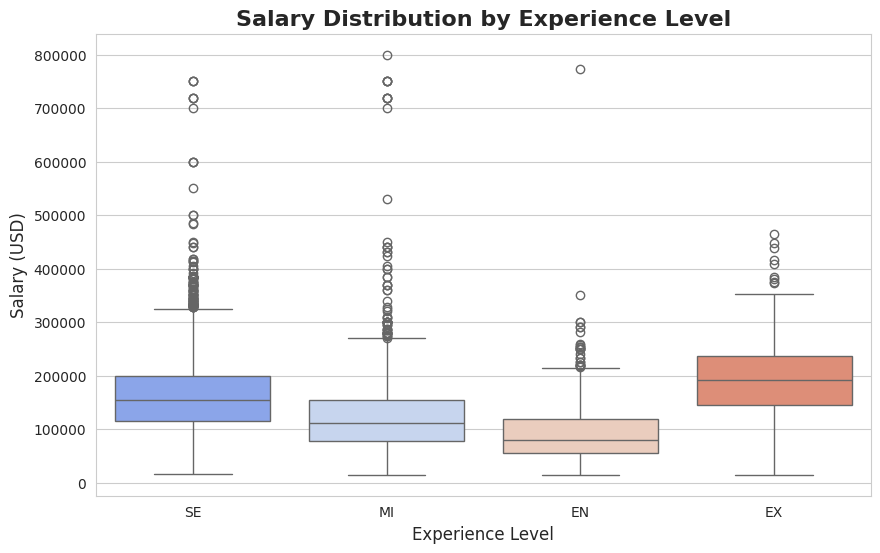

In [ ]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
ax = sns.boxplot(
    data=Datasetsalary_2024,
    x="experience_level",
    y="salary_in_usd",
    palette="coolwarm"
)
plt.title("Salary Distribution by Experience Level", fontsize=16, weight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Salary (USD)", fontsize=12)

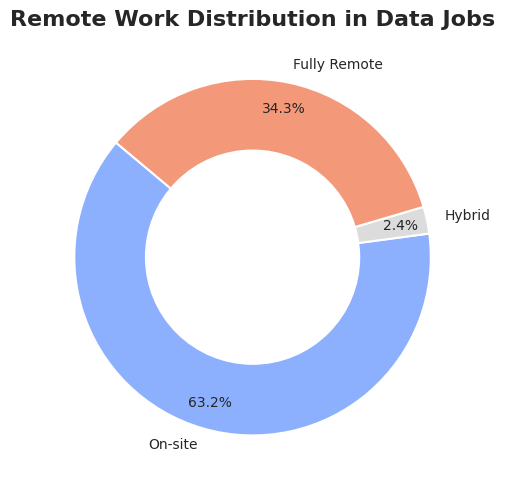

In [ ]:
remote_counts = Datasetsalary_2024['remote_ratio'].value_counts().sort_index()
labels = ['On-site', 'Hybrid', 'Fully Remote']
colors = sns.color_palette("coolwarm", 3)
plt.figure(figsize=(5, 5))
plt.pie(
    remote_counts,
    labels=labels,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=140,
    colors=colors,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Remote Work Distribution in Data Jobs", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

In [1]:
Top10_company_location_vs_salary=Datasetsalary_2024.groupby('company_location')['salary']\
                              .mean() \
                              .sort_values(ascending=False) \
                              .head(10)

plt.figure(figsize=(14,6))
ax = plt.subplots(
    x=Top10_company_size_vs_salary_duration.values,
    y=Top10_company_size_vs_salary_duration.index,
    palette="coolwarm")
plt.title("Top10_company_location_v_salary", fontsize=16, weight='bold')
plt.xlabel("Salary", fontsize=12)
plt.ylabel("Company Location", fontsize=12)
for i, v in enumerate(Top10_company_location_vs_salary.values):
    ax.text(v + 100, i, f"${int(v):,}", va='center', fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

NameError: name 'Datasetsalary_2024' is not defined

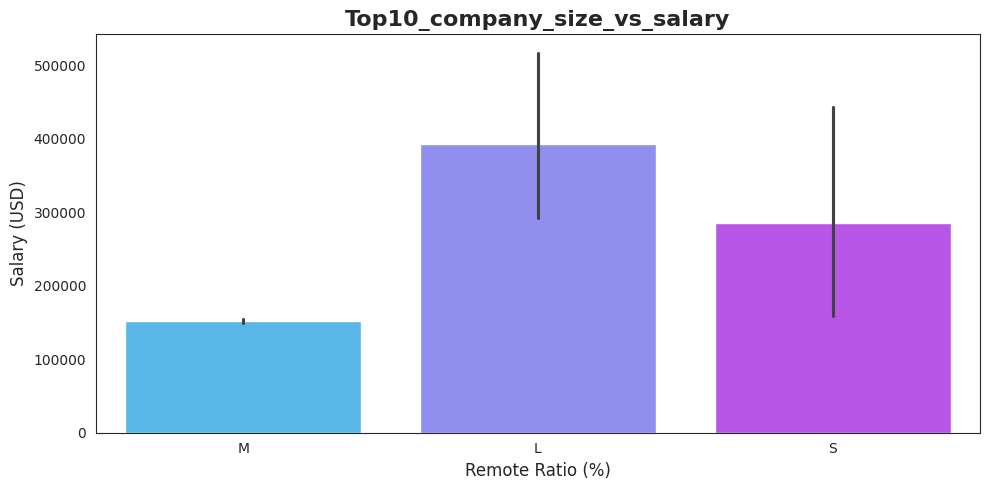

In [ ]:
sns.set_style(style="white")
plt.figure(figsize=(10,5))
ax=sns.barplot(
    x='company_size',
    y='salary',
    data=Datasetsalary_2024,
    palette='cool'
)
plt.title("Top10_company_size_vs_salary", fontsize=16, weight='bold')
plt.xlabel("Remote Ratio (%)", fontsize=12)
plt.ylabel("Salary (USD)", fontsize=12)
plt.tight_layout()
plt.show()